# 11_数据预处理方法-数据平衡

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 补齐分步案例中的导入、占位调用和空图；SMOTE 邻居数改为在训练集内部选取。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天和大家来聊聊数据预处理方法中的数据平衡\~

#### 什么是“数据平衡”？

打个比方：

你在做一个“识别猫和狗”的AI模型。你收集了1000张猫的照片，但只有100张狗的照片。你把这数据喂给模型，它大概率会学会“猫”的特征，而对“狗”就学不太好，因为“狗”的例子太少了。

这时候就出现了一个问题：**数据不平衡**！

简单来说：

> **数据平衡就是让每一类数据的数量尽量差不多，防止模型偏心某一类。**

#### 为什么要做数据平衡？几点原因：

- **防止模型“偏心”**：如果大多数数据是“猫”，模型就会“偷懒”学会总是猜猫。
- **提升小类别的识别能力**：比如狗虽然数据少，但我们也希望模型能学会识别。
- **提高整体模型效果**：平衡数据后，模型学得更全面，预测也更准。

#### 常见的数据平衡方法有哪些？

##### 1. 欠采样（下采样）Undersampling

- 把“多的那一类”删掉一部分，和“少的那一类”差不多多。
- 例子：猫有1000张，狗有100张 → 把猫删到只剩100张。
- 优点：简单快速。
- 缺点：可能浪费了很多有用的数据。

##### 2. 过采样（上采样）Oversampling

- 把“少的那一类”复制几份，让数量变多。
- 例子：猫有1000张，狗有100张 → 把狗的图复制成1000张。
- 优点：保留所有数据。
- 缺点：可能过拟合（模型太记住某些样本）。

##### 3. 合成少数类样本（SMOTE等）

- 不直接复制，而是通过“插值”生成一些新样本，让少的类变多。
- 就像“把两个狗照片之间的特征混合”生成新的狗图。
- 优点：比复制更智能。
- 缺点：需要理解和调整算法。

数据平衡就是在数据预处理阶段，让“每种情况的数据”都尽量平均一些，这样模型才能“公平地学习”，不给任何一类“开小灶”或者“冷落”。

## 原理详解

### 二分类问题设定

设训练数据集为：


$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N, \quad x_i \in \mathbb{R}^d, \quad y_i \in \{0, 1\}
$$


其中：

- $x_i$ 为第 $i$ 个样本的特征向量，维度为 $d$
- $y_i$ 是标签，取值为 0 或 1（表示两个类别）

假设类别 1（正类）的样本数为 $N_1$，类别 0（负类）的样本数为 $N_0$。

如果 $N_1 \ll N_0$ 或 $N_0 \ll N_1$，我们称数据是**不平衡的**。

目标是：对原始数据集 $\mathcal{D}$ 进行处理，使得处理后的数据集 $\mathcal{D}'$ 满足 $N_1' \approx N_0'$。

### 欠采样（Undersampling）

从样本数量较多的类别中**随机删除样本**，以减小其数量，从而与少数类匹配。

#### 数学表达

若 $N_0 > N_1$，则从负类中随机选取 $N_1$ 个样本，使得新的数据集为：


$$
\mathcal{D}' = \mathcal{D}_1 \cup \hat{\mathcal{D}}_0, \quad \text{其中 } |\hat{\mathcal{D}}_0| = N_1
$$


注意：

- 该方法基于概率采样，常使用**均匀分布抽样**。
- 假设原始负类数据为 $\mathcal{D}_0 = \{x_i | y_i = 0\}$，则：


$$
\hat{\mathcal{D}}_0 \sim \text{RandomSample}(\mathcal{D}_0, N_1)
$$


可能丢弃有代表性的数据，导致信息损失。

### 过采样（Oversampling）

从样本数量较少的类别中**重复抽样**（有放回），生成更多样本以匹配多数类数量。

#### 数学表达

若 $N_1 < N_0$，则从正类中有放回地采样 $N_0 - N_1$ 个样本，构建扩展集合 $\tilde{\mathcal{D}}_1$：


$$
\tilde{\mathcal{D}}_1 \sim \text{RandomSampleWithReplacement}(\mathcal{D}_1, N_0 - N_1)
$$


则新的数据集为：


$$
\mathcal{D}' = \mathcal{D}_0 \cup (\mathcal{D}_1 \cup \tilde{\mathcal{D}}_1)
$$


不丢数据，但可能导致过拟合（模型记住重复样本）。

### SMOTE（合成少数类样本）

使用**少数类样本之间的线性插值**生成“虚拟”新样本。

#### 数学基础

对于每一个少数类样本 $x_i \in \mathcal{D}_1$，从其 $k$ 个最近邻（同属少数类）中随机选一个 $x_{\text{NN}}$，生成新样本：


$$
x_{\text{new}} = x_i + \lambda (x_{\text{NN}} - x_i), \quad \lambda \sim U(0, 1)
$$


即：

- 从原点 $x_i$ 朝着邻居 $x_{\text{NN}}$ 的方向前进 $\lambda$ 的比例，生成新样本。

#### 公式说明

1. 给定样本 $x_i \in \mathbb{R}^d$
2. 找到 $k$-近邻集合 $\mathcal{N}_i = \{x_j\}_{j=1}^k \subset \mathcal{D}_1 \setminus \{x_i\}$
3. 从 $\mathcal{N}_i$ 中随机选一个邻居 $x_{\text{NN}}$
4. 生成：$x_{\text{new}} = x_i + \lambda (x_{\text{NN}} - x_i)$

这个过程等价于在 $x_i$ 和 $x_{\text{NN}}$ 之间做一个线段插值。也可以扩展为：

- 多点插值（混合多个邻居）
- 加入扰动项（提高多样性）

### 算法流程

1. 对每个少数类样本 $x_i$：

   - 找到其 $k$ 个最近邻
   - 随机选一个邻居 $x_{\text{NN}}$
   - 使用插值公式生成新样本
2. 重复上述过程直到生成指定数量的新样本

### 优点

- 比简单过采样更有多样性，减少重复样本的问题
- 保持特征空间分布结构

### 多分类场景的扩展

设数据有 $C$ 个类别，每类样本数为 $N_c$，定义：

- 最大类别数：$N_{\max} = \max_c N_c$
- 平衡目标：$N_c' = N_{\max}$ 对每类都进行过采样；或 $N_c' = N_{\min}$ 对每类都欠采样；或自定义比例

SMOTE 也可以推广到多分类，通常只对样本较少的类别做合成。

### 评估数据平衡效果的指标（理论上）

虽然数据平衡本身不是模型评估方法，但其影响可以通过以下指标体现：

- G-Mean（几何均值）：


$$
\text{G-Mean} = \sqrt{\text{Recall}_{+} \cdot \text{Recall}_{-}}
$$


- Balanced Accuracy：


$$
\text{BA} = \frac{1}{2} \left( \frac{TP}{TP + FN} + \frac{TN}{TN + FP} \right)
$$


- F1-score、AUC 等也是间接反映数据平衡影响的指标。

## 完整案例

给出一个不平衡的数据集，然后进行每一步的处理，最后针对 SMOTE 算法的优化思路。

### 1. 生成高维不平衡数据集

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
import random

X, y = make_classification(
    n_samples=10000,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    flip_y=0,
    random_state=42
)

构造一个二分类的合成数据集，总样本数 10000，特征数 2，正负样本比例为 10%:90%（模拟现实中常见的类别不平衡场景）。

参数：

- `n_samples`：样本总数。
- `n_features`：特征维度为 2，便于后面绘制散点图。
- `weights`：类别权重，`[0.9,0.1]` 表示类别 0 占 90%，类别 1 占 10%。
- `flip_y=0`：不引入标签噪声，保持「纯净」分布。

### 2. 划分训练集和测试集

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

将数据集按后续对训练集做平衡处理，用测试集评估模型泛化性能。

### 3. 可视化原始训练集分布

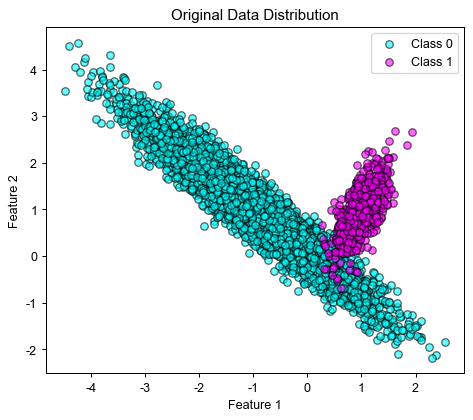

In [4]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            label='Class 0', alpha=0.6, c='cyan', edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            label='Class 1', alpha=0.6, c='magenta', edgecolor='k')
plt.title('Original Data Distribution')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

绘制训练集在二维特征空间中的散点分布。分别标记两类，边缘黑色突出点的形状；`alpha=0.6` 保证叠加后仍可分辨。

![原文参考图，当前结果见代码输出](attachments/img_012.png)

直观展示类别不平衡：大部分点集中在类别 0（青色），类别 1（洋红）稀疏。

### 4. 欠采样

In [5]:
idx_major = np.where(y_train==0)[0]
idx_minor = np.where(y_train==1)[0]
idx_major_down = np.random.choice(idx_major, size=len(idx_minor), replace=False)
X_rus = np.vstack((X_train[idx_major_down], X_train[idx_minor]))
y_rus = np.hstack((y_train[idx_major_down], y_train[idx_minor]))

从多数类中随机选择与少数类等量的样本，丢弃其余多数类样本。

**步骤**：

1. `idx_major`／`idx_minor` 分别获取多数类和少数类样本的索引。
2. `np.random.choice` 在多数类索引中随机采样，与少数类数量相同。
3. 垂直合并多数类降采样后与少数类，形成平衡后的训练集 `X_rus, y_rus`。

**风险与权衡**：快速简便，但可能丢失多数类的关键信息，导致模型整体性能下降。

### 5. 过采样（Random Oversampling）

In [6]:
idx_minor_up = np.random.choice(idx_minor, size=len(idx_major), replace=True)
X_ros = np.vstack((X_train[idx_major], X_train[idx_minor_up]))
y_ros = np.hstack((y_train[idx_major], y_train[idx_minor_up]))

对少数类样本进行有放回重复采样，使得其数量补足到多数类水平。

**步骤**：

1. 在少数类索引中有放回地抽样，使样本数等于多数类。
2. 与原多数类样本合并，生成平衡后的训练集 `X_ros, y_ros`。

**优点与缺点**：保留所有原始样本，但复制容易导致过拟合（模型过度记忆某些少数类样本特征）。

### 6. 自定义 SMOTE 实现

In [7]:
def custom_smote(X, y, k=5):
    X_min = X[y==1]
    X_maj = X[y==0]
    n_generate = len(X_maj) - len(X_min)
    nn = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]
    synthetic = []
    for _ in range(n_generate):
        idx = random.randint(0, len(X_min)-1)
        nn_idx = random.choice(neighbors[idx])
        diff = X_min[nn_idx] - X_min[idx]
        gap = np.random.rand()
        synthetic.append(X_min[idx] + gap * diff)
    X_smt = np.vstack((X, synthetic))
    y_smt = np.hstack((y, np.ones(len(synthetic))))
    return X_smt, y_smt

X_smt, y_smt = custom_smote(X_train, y_train, k=5)

**算法核心**：

1. **邻居选择**：对少数类样本构建 $k$-近邻图。
2. **线性插值**：在随机选取的样本 $x_i$ 与其邻居 $x_{nn}$ 间，以随机比例 $\lambda\in[0,1]$ 插值，生成合成样本：


$$
x_{\text{new}} = x_i + \lambda \,(x_{nn}-x_i)
$$


1. **样本数补齐**：重复插值直到少数类数量与多数类持平。

**优点**：比简单复制更具多样性，缓解过拟合；保留原始多数类全部信息。

**参数**$k$：邻居数量，影响合成样本的多样性与质量。

### 7. 平衡后数据分布可视化对比

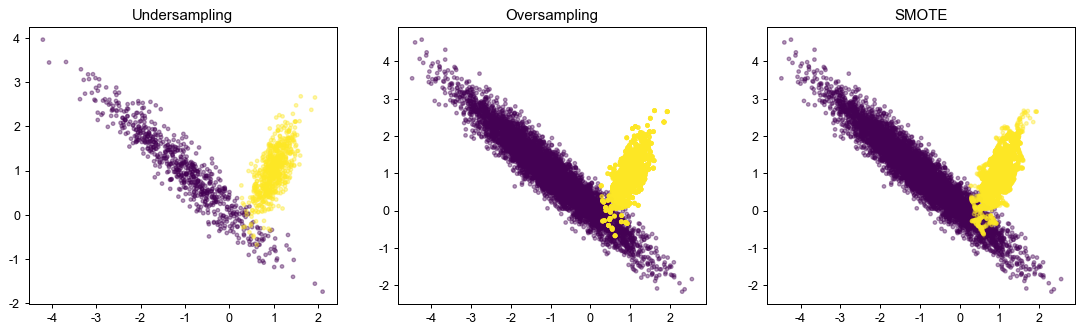

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, (Xb, yb, label) in zip(axs, [(X_rus, y_rus, 'Undersampling'), (X_ros, y_ros, 'Oversampling'), (X_smt, y_smt, 'SMOTE')]):
    ax.scatter(Xb[:, 0], Xb[:, 1], c=yb, s=8, alpha=0.4)
    ax.set_title(label)
plt.show()

并排对比三种平衡方法后的训练集分布。

![原文参考图，当前结果见代码输出](attachments/img_013.png)

- 欠采样后稀疏但对称；
- 过采样后少数类“堆积”在原位置；
- SMOTE 后少数类沿决策边界形成“云团”，覆盖更广区域。

### 8. 训练逻辑回归并比较性能

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2700
           1       0.99      0.94      0.97       300

    accuracy                           0.99      3000
   macro avg       0.99      0.97      0.98      3000
weighted avg       0.99      0.99      0.99      3000

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2700
           1       0.87      0.98      0.92       300

    accuracy                           0.98      3000
   macro avg       0.93      0.98      0.95      3000
weighted avg       0.98      0.98      0.98      3000

              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2700
           1       0.88      0.98      0.92       300

    accuracy                           0.98      3000
   macro avg       0.94      0.98      0.96      3000
weighted avg       0.99      0.98      0.98      3000

              preci

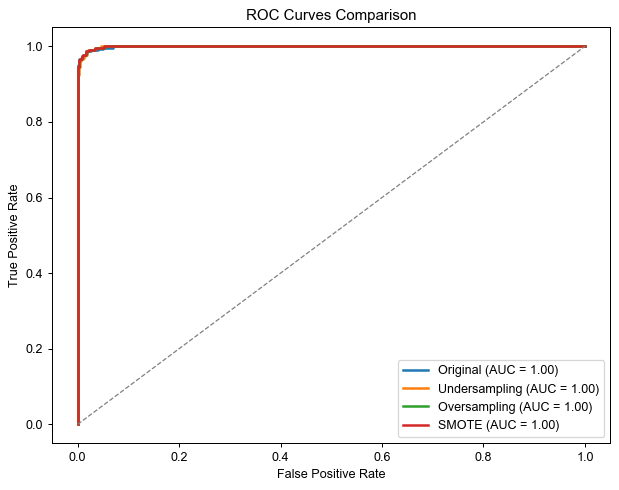

In [9]:
def evaluate_and_plot(X_tr, y_tr, label):
    model = LogisticRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(classification_report(y_test, y_pred))
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.figure(figsize=(8, 6))
for Xb, yb, label in [(X_train, y_train, 'Original'), (X_rus, y_rus, 'Undersampling'), (X_ros, y_ros, 'Oversampling'), (X_smt, y_smt, 'SMOTE')]:
    evaluate_and_plot(Xb, yb, label)
plt.plot([0,1], [0,1], '--', lw=1, color='gray')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**流程**：

1. 对原始、欠采样、过采样、SMOTE 四个训练集分别训练 `LogisticRegression`。
2. 在同一张图上绘制 ROC 曲线，比较 AUC 值。
3. 打印详细的 `precision`、`recall`、`f1-score` 等指标。

![原文参考图，当前结果见代码输出](attachments/img_014.png)

定量评估不同平衡策略对分类性能的提升与侧重点。例如：

- 欠采样可能提升少数类 `recall` 但整体 `precision` 略降；
- 过采样 `precision`、`recall` 均提升但存在过拟合风险；
- SMOTE 通常取得最优的 AUC 平衡。

### 9. SMOTE 算法优化：动态选择 $k$-neighbors

In [10]:
# 只在训练数据内部选择 SMOTE 邻居数。
Xa, Xv, ya, yv = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=7)
best_auc, best_k = -np.inf, None
for k in [3, 5, 7, 9]:
    X_opt, y_opt = custom_smote(Xa, ya, k=k)
    candidate = LogisticRegression(max_iter=1000).fit(X_opt, y_opt)
    score = auc(*roc_curve(yv, candidate.predict_proba(Xv)[:, 1])[:2])
    print(f'k={k}, validation AUC={score:.4f}')
    if score > best_auc:
        best_auc, best_k = score, k
X_final, y_final = custom_smote(X_train, y_train, k=best_k)
final_model = LogisticRegression(max_iter=1000).fit(X_final, y_final)
print('Selected k:', best_k)
print('Held-out test AUC:', auc(*roc_curve(y_test, final_model.predict_proba(X_test)[:, 1])[:2]))

k=3, validation AUC=0.9986
k=5, validation AUC=0.9986
k=7, validation AUC=0.9986
k=9, validation AUC=0.9986
Selected k: 5
Held-out test AUC: 0.9991185185185185


**优化目标**：寻找最优的邻居数 $k$，使得 SMOTE 生成的样本既有足够多样性，又不过度偏离少数类分布。

根据实验输出选择 AUC 最高时的 $k$ 值。

- 可引入更多候选 $k$ 或结合交叉验证；
- 考虑 `Borderline-SMOTE`、`ADASYN` 等变种；
- 在高维空间可使用 PCA 降维后再合成。

### 完整代码

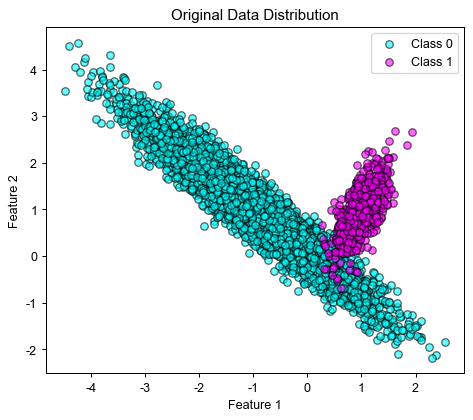

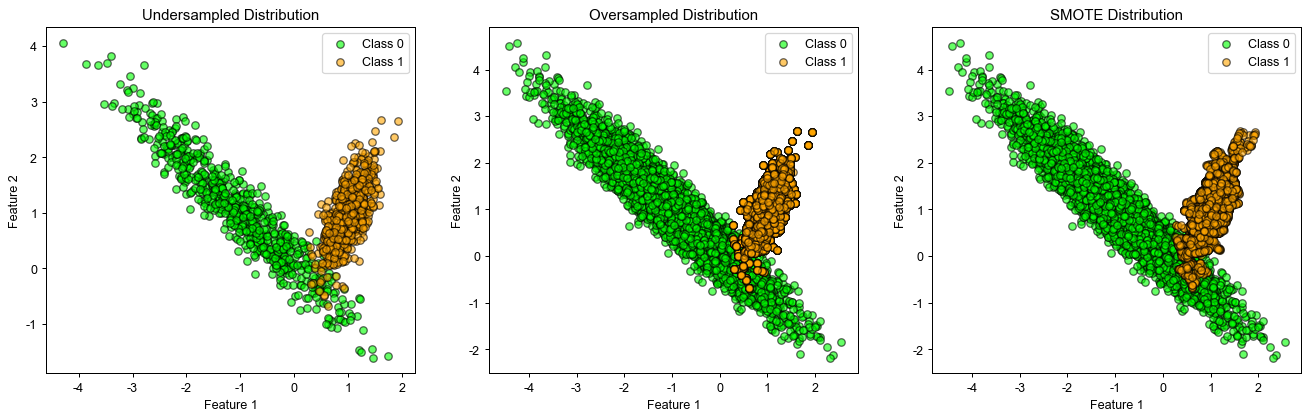

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
import random

# 1. 生成高维不平衡数据集
X, y = make_classification(n_samples=10000, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, weights=[0.9, 0.1],
                           flip_y=0, random_state=42)

# 2. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    stratify=y, 
                                                    random_state=42)

# 3. 可视化原始训练数据分布
plt.figure(figsize=(6, 5))
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], 
            label='Class 0', alpha=0.6, c='cyan', edgecolor='k')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], 
            label='Class 1', alpha=0.6, c='magenta', edgecolor='k')
plt.title('Original Data Distribution')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

# 4. 欠采样
idx_major = np.where(y_train==0)[0]
idx_minor = np.where(y_train==1)[0]
idx_major_down = np.random.choice(idx_major, size=len(idx_minor), replace=False)
X_rus = np.vstack((X_train[idx_major_down], X_train[idx_minor]))
y_rus = np.hstack((y_train[idx_major_down], y_train[idx_minor]))

# 5. 过采样
idx_minor_up = np.random.choice(idx_minor, size=len(idx_major), replace=True)
X_ros = np.vstack((X_train[idx_major], X_train[idx_minor_up]))
y_ros = np.hstack((y_train[idx_major], y_train[idx_minor_up]))

# 6. 自定义SMOTE
def custom_smote(X, y, k=5):
    X_min = X[y==1]
    X_maj = X[y==0]
    n_min, _ = X_min.shape
    n_maj = X_maj.shape[0]
    n_generate = n_maj - n_min

    nn = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]

    synthetic = []
    for _ in range(n_generate):
        idx = random.randint(0, n_min - 1)
        nn_idx = random.choice(neighbors[idx])
        diff = X_min[nn_idx] - X_min[idx]
        gap = np.random.rand()
        synthetic.append(X_min[idx] + gap * diff)
    X_smt = np.vstack((X, np.array(synthetic)))
    y_smt = np.hstack((y, np.ones(len(synthetic))))
    return X_smt, y_smt

X_smt, y_smt = custom_smote(X_train, y_train, k=5)

# 7. 可视化平衡后数据分布
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, (Xb, yb, title) in zip(axs, 
                               [(X_rus, y_rus, 'Undersampled Distribution'),
                                (X_ros, y_ros, 'Oversampled Distribution'),
                                (X_smt, y_smt, 'SMOTE Distribution')]):
    ax.scatter(Xb[yb==0, 0], Xb[yb==0, 1], 
               label='Class 0', alpha=0.6, c='lime', edgecolor='k')
    ax.scatter(Xb[yb==1, 0], Xb[yb==1, 1], 
               label='Class 1', alpha=0.6, c='orange', edgecolor='k')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend()
plt.show()

---- Original ----
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2700
           1       0.99      0.94      0.97       300

    accuracy                           0.99      3000
   macro avg       0.99      0.97      0.98      3000
weighted avg       0.99      0.99      0.99      3000

---- Undersampled ----
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      2700
           1       0.86      0.98      0.92       300

    accuracy                           0.98      3000
   macro avg       0.93      0.98      0.95      3000
weighted avg       0.98      0.98      0.98      3000

---- Oversampled ----
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2700
           1       0.89      0.98      0.93       300

    accuracy                           0.99      3000
   macro avg       0.94      0.98      0.96      3000
weighted a

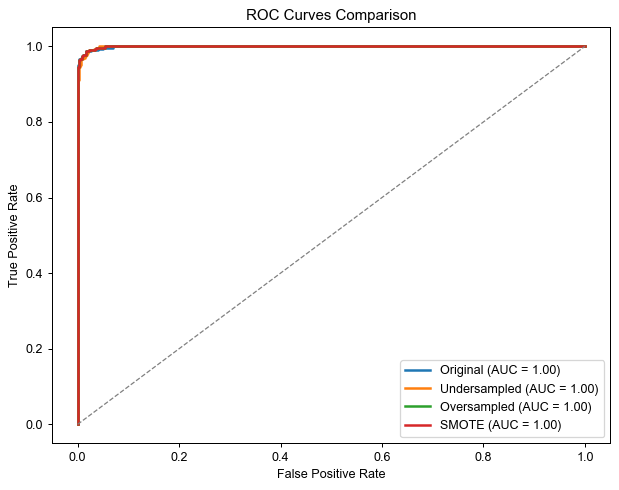

k=3, validation AUC=0.9986
k=5, validation AUC=0.9986
k=7, validation AUC=0.9986
k=9, validation AUC=0.9986
Selected k: 3
Held-out test AUC: 0.999137037037037


In [12]:
# 8. 训练逻辑回归并比较性能
def evaluate_and_plot(X_tr, y_tr, label):
    model = LogisticRegression()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, y_pred, output_dict=True)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    print(f'---- {label} ----')
    print(classification_report(y_test, y_pred))
    plt.plot(fpr, tpr, lw=2, label=f'{label} (AUC = {roc_auc:.2f})')

plt.figure(figsize=(8, 6))
evaluate_and_plot(X_train, y_train, 'Original')
evaluate_and_plot(X_rus, y_rus, 'Undersampled')
evaluate_and_plot(X_ros, y_ros, 'Oversampled')
evaluate_and_plot(X_smt, y_smt, 'SMOTE')
plt.plot([0, 1], [0, 1], linestyle='--', lw=1, color='gray')
plt.title('ROC Curves Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

# 只在训练数据内部选择 SMOTE 邻居数。
Xa, Xv, ya, yv = train_test_split(X_train, y_train, test_size=0.25, stratify=y_train, random_state=7)
best_auc, best_k = -np.inf, None
for k in [3, 5, 7, 9]:
    X_opt, y_opt = custom_smote(Xa, ya, k=k)
    candidate = LogisticRegression(max_iter=1000).fit(X_opt, y_opt)
    score = auc(*roc_curve(yv, candidate.predict_proba(Xv)[:, 1])[:2])
    print(f'k={k}, validation AUC={score:.4f}')
    if score > best_auc:
        best_auc, best_k = score, k
X_final, y_final = custom_smote(X_train, y_train, k=best_k)
final_model = LogisticRegression(max_iter=1000).fit(X_final, y_final)
print('Selected k:', best_k)
print('Held-out test AUC:', auc(*roc_curve(y_test, final_model.predict_proba(X_test)[:, 1])[:2]))

以上代码完整覆盖了：

1. 数据平衡的三种经典方法：欠采样、过采样、自定义 SMOTE；
2. 对比可视化，帮助直观理解平衡前后的数据分布差异；
3. 量化评估（分类报告、ROC/AUC）展示模型表现；
4. SMOTE 参数优化，体现算法实用性与可调优空间。

## 模型分析

上面使用的数据平衡方法，主要是围绕欠采样、过采样和 SMOTE 进行的。

### 优缺点

**优点**：

1. **有效提升少数类的识别能力**：原始数据集中类别极不平衡（90% vs 10%），如果不做处理，模型会倾向多数类，忽略少数类。而数据平衡方法显著提升了少数类的 recall 和 F1-score。
2. **增强模型的泛化能力**：使用如 SMOTE 这类合成方法，不仅增加了少数类样本数量，还拓展了少数类在特征空间的覆盖范围，使得模型能学习到更广泛的判别边界。
3. **减少过拟合风险**：相比简单重复样本的随机过采样，SMOTE 更容易生成分布合理的合成样本，减少模型过拟合于某几个样本点的问题。
4. **可视化直观分析，便于调试**：由于示例数据是二维的，使用平衡处理前后的可视化可以清晰地看到数据的分布变化，增强了方法的解释性。

**缺点**：

1. **引入噪声风险**：SMOTE 在特征空间中合成的新样本并不一定真实可靠，特别是在类别边界模糊的区域，可能导致混淆、降低精度。
2. **计算复杂度增加**：SMOTE 需要查找最近邻，插值生成新样本，在高维数据集上计算成本较高；如果使用更复杂的平衡方法如 ADASYN，训练耗时可能更长。
3. **参数敏感性问题**：如邻居数 $k$ 对 SMOTE 效果有重要影响，如果选取不当，可能造成生成样本质量低劣，反而拉低整体模型性能。
4. **对高维稀疏数据效果有限**：在文本、图像等高维数据中，SMOTE 效果不如在结构化数据中明显，有时需要配合降维等预处理手段。

### 相似算法的对比

| 方法名称 | 核心思想 | 优点 | 缺点 | 适用场景 |
|-|-|-|-|-|
| **Random Undersampling** | 从多数类中随机删除样本，使类均衡 | 快速、简单，节省存储空间 | 可能丢失有价值信息，影响模型表现 | 多数类样本量极大，训练资源有限的情况 |
| **Random Oversampling** | 对少数类进行复制补齐样本数 | 保留所有原始数据，简单易行 | 易导致过拟合，缺乏多样性 | 少数类样本较少但特征重要、不希望丢失的情况 |
| **SMOTE** | 通过 K 近邻在少数类样本之间合成新样本 | 增强多样性，缓解过拟合 | 可能引入噪声样本，参数敏感 | 少数类样本太少、希望生成多样性数据时优选 |
| **Borderline-SMOTE** | 只在决策边界的少数类样本附近插值 | 更关注判别边界，提升 recall | 对边界判断依赖性强，若边界不明显则不稳定 | 类别重叠明显或关注模型 recall 的场景 |
| **ADASYN** | 自动控制样本生成数量，边界难分类样本生成更多样本 | 针对性强、生成样本分布更贴近实际 | 计算复杂度更高，容易过度偏向边界区域 | 类别区分困难、希望改进边界判别能力时使用 |
| **Tomek Links 清洗** | 清除边界重叠样本（多为易混样本） | 降低噪声、增强分类边界清晰度 | 可能删除真实但难分类的数据，导致 recall 下降 | 作为其他方法的补充清洗步骤，优化边界 |

### 何时优选 SMOTE 类方法？何时考虑其他算法？

#### 优选 SMOTE 的情况：

- 少数类样本极度稀缺，无法获得更多实际数据；
- 希望生成新的、合理分布的样本而非简单复制；
- 对 recall 和 F1-score 要求高，例如医学、反欺诈场景；
- 多数类信息充分，不希望因欠采样而损失重要模式。

#### 考虑其他算法的情况：

- 多数类样本过多、训练资源有限 → 选择 Random Undersampling；
- 少数类样本重要、但数量尚可 → 可使用 Random Oversampling；
- 类别严重重叠，判别边界模糊 → Borderline-SMOTE 更有效；
- 对边界样本学习更敏感，希望动态控制生成样本 → 使用 ADASYN；
- 模型训练前需清理噪声数据 → 可配合 Tomek Links 进行清洗。

### 总结

在本案例中，SMOTE 和 Oversampling 显著提升了少数类的识别能力，验证了数据平衡预处理在类别不均衡问题中的有效性。然而，没有一种方法是完美适用所有情况的。最佳策略往往是结合问题场景、数据分布和资源限制综合考虑，并通过实验验证选出最优方案。

数据平衡不只是简单地“让样本数量一样”，它本质是对特征空间的重构与优化，只有理解其背后数学逻辑和模型表现之间的关系，才能真正发挥其价值。